# Supply Chain Analysis: Order Delivery, Shipping Delays, and Profitability

## 1. Project Overview

### Project Description
This project focuses on analyzing supply chain operations to understand order processing time, shipping performance, delivery delays, and profitability. Using Python and data analysis libraries, the project explores patterns in shipping duration, scheduled delivery times, regional delays, shipping modes, and monthly sales and profitability.

### Problem Statement
Supply chain delays can affect customer satisfaction, operational efficiency, and business profitability. The objective of this project is to analyze historical order and shipping data to identify patterns associated with late deliveries, understand the factors related to shipping delays, and examine how delivery performance varies across different regions, shipping modes, payment types, and time periods.

### Project Objectives
- Analyze actual shipping durations and compare them with scheduled shipping times.
- Calculate key delivery performance metrics, including total orders, late deliveries, and on-time delivery percentage.
- Examine the distribution of shipping delays and identify patterns in delivery performance.
- Analyze profitability across different delay durations.
- Identify regions, shipping modes, payment types, and departments associated with higher delay rates.
- Explore relationships between order processing time, shipping duration, and late delivery risk.
- Analyze monthly sales and profitability trends.
- Develop data-driven insights and recommendations to support supply chain decision-making.

### Tools and Technologies
- **Programming Language:** Python
- **Environment:** Jupyter Notebook
- **Data Manipulation:** Pandas, NumPy
- **Data Visualization:** Matplotlib, Seaborn
- **Statistical Analysis:** Descriptive statistics and correlation analysis
- **Dataset:** DataCo Supply Chain Dataset (`DataCoSupplyChainDataset.csv`)

### Project Workflow
1. Data loading and initial inspection
2. Data cleaning and preprocessing
3. Feature engineering
4. Exploratory Data Analysis (EDA)
5. Delivery performance and profitability analysis
6. Business insights and recommendations
7. Conclusion

## 02. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

viridis_colors = cm.viridis(np.linspace(0, 1, 5))
primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color = '#800000'
neutral_color = viridis_colors[4]
custom_palette = viridis_colors

## 03. Load the Dataset

In [3]:
df=pd.read_csv("/content/DataCoSupplyChainDataset.csv",encoding="latin-1")

In [4]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/15/2018 11:24,Standard Class


In [5]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [6]:
df.shape

(35768, 53)

## 04. Initial Data Inspection

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35768 entries, 0 to 35767
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Type                           35768 non-null  object 
 1   Days for shipping (real)       35768 non-null  int64  
 2   Days for shipment (scheduled)  35768 non-null  int64  
 3   Benefit per order              35768 non-null  float64
 4   Sales per customer             35768 non-null  float64
 5   Delivery Status                35768 non-null  object 
 6   Late_delivery_risk             35768 non-null  int64  
 7   Category Id                    35768 non-null  int64  
 8   Category Name                  35768 non-null  object 
 9   Customer City                  35768 non-null  object 
 10  Customer Country               35768 non-null  object 
 11  Customer Email                 35768 non-null  object 
 12  Customer Fname                 35768 non-null 

In [8]:
df.isnull().sum()

,0
Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,0


In [9]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,35768.000000,35768.000000,35768.000000,35768.000000,35768.000000,35768.000000,35768.000000,35767.000000,35768.000000,35768.000000,...,35768.000000,35768.000000,35768.000000,35768.000000,4880.000000,35768.000000,35768.000000,0.0,35767.000000,35767.0
mean,3.478081,2.960328,21.576829,177.009343,0.564471,26.459098,6803.501454,35787.191937,4.815338,29.690917,...,2.452807,197.182712,177.009343,21.576829,55527.052869,567.127432,26.459098,NaN,117.481821,0.0
std,1.587169,1.370873,106.116454,124.838215,0.495833,15.071120,4325.744100,37612.996995,1.554261,9.799416,...,1.555097,137.980379,124.838215,106.116454,31965.665580,312.133357,15.071120,NaN,133.579883,0.0
min,0.000000,0.000000,-3366.000000,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,17.982491,...,1.000000,9.990000,7.490000,-3366.000000,1453.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,6.380000,97.489998,0.000000,17.000000,3247.000000,725.000000,4.000000,18.264801,...,1.000000,119.970001,97.489998,6.380000,23320.000000,365.000000,17.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,29.400000,145.559998,1.000000,24.000000,6537.000000,19140.000000,5.000000,33.133568,...,2.000000,159.960007,145.559998,29.400000,60505.000000,502.000000,24.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,62.590000,247.500000,1.000000,36.000000,9909.250000,78228.000000,6.000000,39.279617,...,4.000000,299.950012,247.500000,62.590000,90004.000000,786.000000,36.000000,NaN,129.990005,0.0
max,6.000000,4.000000,684.000000,1759.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1759.989990,684.000000,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [10]:
for col in df.columns:
  if df[col].nunique()<10:
    print(f'\n{col},value_counts:')
    print(df[col].value_counts())


Type,value_counts:
Type
DEBIT       13983
CASH         9138
TRANSFER     6674
PAYMENT      5973
Name: count, dtype: int64

Days for shipping (real),value_counts:
Days for shipping (real)
2    12461
6     5550
4     5543
3     5461
5     5384
1      707
0      662
Name: count, dtype: int64

Days for shipment (scheduled),value_counts:
Days for shipment (scheduled)
4    21969
1     6851
2     5579
0     1369
Name: count, dtype: int64

Delivery Status,value_counts:
Delivery Status
Late delivery        20190
Advance shipping      8492
Shipping on time      6045
Shipping canceled     1041
Name: count, dtype: int64

Late_delivery_risk,value_counts:
Late_delivery_risk
1    20190
0    15578
Name: count, dtype: int64

Customer Country,value_counts:
Customer Country
EE. UU.        22002
Puerto Rico    13766
Name: count, dtype: int64

Customer Email,value_counts:
Customer Email
XXXXXXXXX    35768
Name: count, dtype: int64

Customer Password,value_counts:
Customer Password
XXXXXXXXX    35768
Name:

In [11]:
df.duplicated().sum()

np.int64(0)

## 05. Data Cleaning & Preprocessing

In [12]:
columns_to_drop = [
    'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
     'Product Card Id',
    'Product Category Id',
    'Benefit per order',
    'Product Status',
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market'
]

df.drop(columns=columns_to_drop, inplace=True)

In [13]:
df["shipping date (DateOrders)"] = pd.to_datetime(
    df["shipping date (DateOrders)"],
    format="%m/%d/%Y %H:%M",
    errors="coerce"
)

In [14]:
df["order date (DateOrders)"] = pd.to_datetime(
    df["order date (DateOrders)"],
    format="%m/%d/%Y %H:%M",
    errors="coerce"
)

## 06. Feature Engineering

In [15]:
df=df[df["Delivery Status"]!='Shipping canceled']

In [16]:
df['Order Processing Time']=(df['shipping date (DateOrders)']-df['order date (DateOrders)']).dt.days

In [17]:
df['Delay']=df['Order Processing Time']-df['Days for shipment (scheduled)']

In [18]:
df['Is_Delayed']=df['Delay']>0

In [19]:
df['order_month']=df['order date (DateOrders)'].dt.month

In [20]:
df['order_day']=df['order date (DateOrders)'].dt.day_name()

In [21]:
df['order_hour']=df['order date (DateOrders)'].dt.hour

In [22]:
df['Profitability Flag']=np.where(df['Order Profit Per Order']> 0,'Profit',np.where(df['Order Profit Per Order']<0,'Loss','Break point'))

In [23]:
df['Profitability Flag'].value_counts()

,count
Profitability Flag,
Profit,28064
Loss,6445
Break point,218


In [24]:
profit_metrics=(df.groupby('Delay')['Order Profit Per Order'].agg(mean_profit='mean',total_profit='sum',order_count='count').reset_index())

In [25]:
profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2.0,25.552459,109543.390004,4287
1,-1.0,20.928483,88004.270263,4205
2,0.0,20.923349,141086.139823,6743
3,1.0,21.328919,254816.600329,11947
4,2.0,21.885909,116892.639712,5341
5,3.0,15.991375,17670.469862,1105
6,4.0,19.420638,21323.859982,1098


In [26]:
delay_distribution=(df['Delay'].value_counts(normalize=True).sort_index()*100).reset_index()

In [27]:
delay_distribution

,Delay,proportion
0,-2.0,12.345217
1,-1.0,12.109083
2,0.0,19.417727
3,1.0,34.403617
4,2.0,15.380407
5,3.0,3.182054
6,4.0,3.161896


In [28]:
def compute_delay_pct_by_category(category):
  cat_df=df.groupby(category).agg(total_orders=("Delay","count"),
                                  late_orders=("Is_Delayed","sum")).reset_index()
  cat_df['delay_pct']=cat_df['late_orders']/cat_df['total_orders']*100
  cat_df=cat_df.sort_values('delay_pct',ascending=False).head(10)
  return cat_df

In [29]:
delay_by_month=(df.groupby("order_month")['Is_Delayed'].mean().reset_index())
delay_by_month["delay_pct"]=delay_by_month['Is_Delayed']*100

delay_by_day=(df.groupby("order_day")['Is_Delayed'].mean().reset_index())
delay_by_day['delay_pct']=delay_by_day['Is_Delayed']*100

delay_by_hour=(df.groupby("order_hour")["Is_Delayed"].mean().reset_index())
delay_by_hour["delay_pct"]=delay_by_hour['Is_Delayed']*100

## 07. Exploratory Data Analysis (EDA)

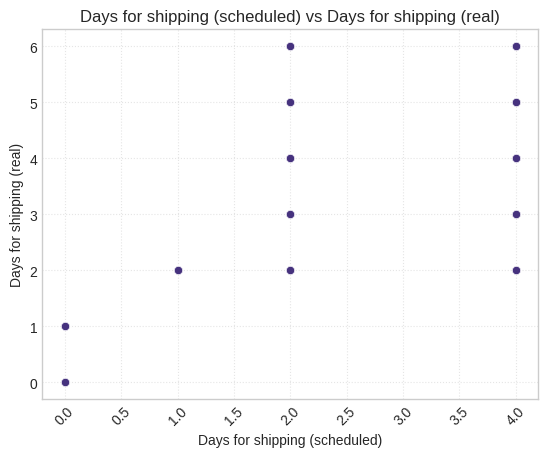

In [30]:
sns.scatterplot(data=df, x='Days for shipment (scheduled)', y='Days for shipping (real)')
plt.title('Days for shipping (scheduled) vs Days for shipping (real)')
plt.xlabel('Days for shipping (scheduled)')
plt.ylabel('Days for shipping (real)')
plt.xticks(rotation=45)
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

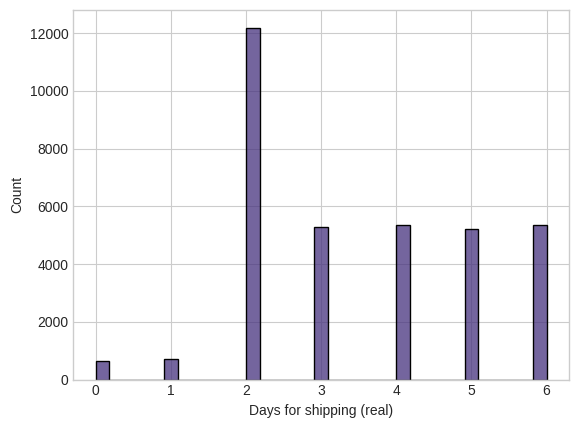

In [31]:
sns.histplot(data=df, x='Days for shipping (real)')
plt.show()

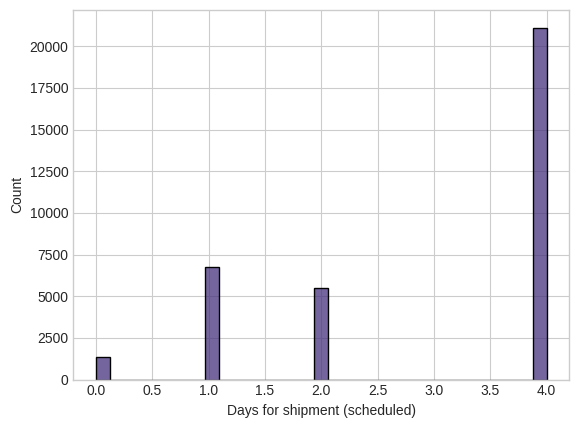

In [32]:
sns.histplot(data=df, x='Days for shipment (scheduled)')
plt.show()


Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2.0,25.6,109543.4,4287
1,-1.0,20.9,88004.3,4205
2,0.0,20.9,141086.1,6743
3,1.0,21.3,254816.6,11947
4,2.0,21.9,116892.6,5341
5,3.0,16.0,17670.5,1105
6,4.0,19.4,21323.9,1098



Delay Distribution(%):


,Delay_Days,Percentage
0,-2.0,12.345217
1,-1.0,12.109083
2,0.0,19.417727
3,1.0,34.403617
4,2.0,15.380407
5,3.0,3.182054
6,4.0,3.161896


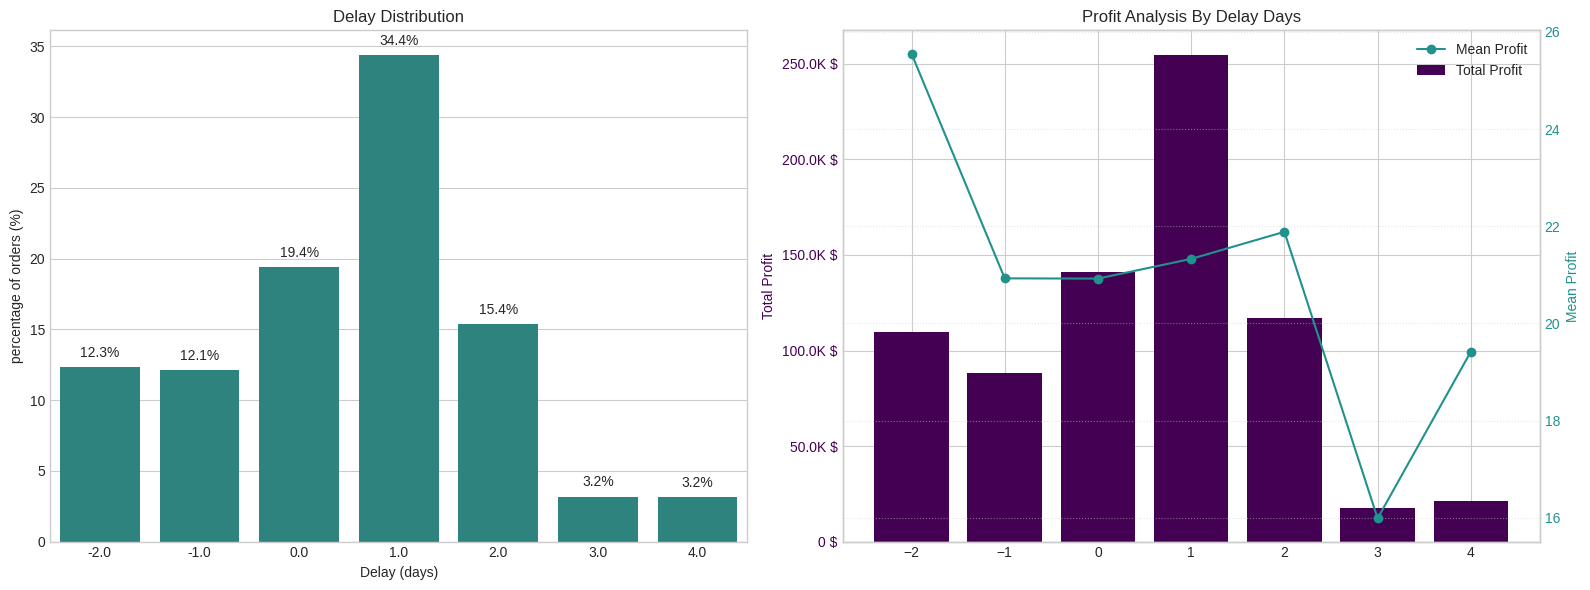

In [33]:
delay_distribution.columns=['Delay_Days','Percentage']

print('\nProfit Metrics by Delay Day:')
display(profit_metrics.round(1))

print('\nDelay Distribution(%):')
display(delay_distribution)

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))

# First subplot : Delay Distribution
sns.barplot(x="Delay_Days",y="Percentage",data=delay_distribution,color=accent_color,ax=ax1)
ax1.set_title("Delay Distribution")
ax1.set_xlabel("Delay (days)")
ax1.set_ylabel('percentage of orders (%)')

for bar in ax1.patches:
  height=bar.get_height()
  ax1.text(bar.get_x()+bar.get_width()/2,height+0.5,f'{height:.1f}%',ha='center',va='bottom')

ax2.set_ylabel("Total Profit",color=primary_color)
ax2.bar(profit_metrics['Delay'],profit_metrics['total_profit'],color=primary_color,label='Total Profit')
ax2.tick_params(axis='y',labelcolor=primary_color)

ax3=ax2.twinx()

ax3.set_xlabel("Delay Days")
ax3.set_ylabel("Mean Profit",color=accent_color)
ax3.plot(profit_metrics['Delay'],profit_metrics['mean_profit'],marker='o',label='Mean Profit',color=accent_color)
ax3.tick_params(axis='y',labelcolor=accent_color)

def format_func(value,tick_number):
  if value>=1e6:
    return f"{value/1e6:.1f}M $"
  elif value >=1e3:
    return f'{value/1e3:.1f}K $'
  else:
    return f"{value:.0f} $"
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

ax3.set_title("Profit Analysis By Delay Days")

lines,labels=ax3.get_legend_handles_labels()
lines2,labels2=ax2.get_legend_handles_labels()
ax3.legend(lines+lines2,labels+labels2,loc='upper right')
ax3.grid(True,linestyle=":",alpha=0.5)

plt.tight_layout()
plt.show()

In [34]:
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

delayed_df = df[df['Delay'] > 0]
metrics = {}
metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)
metrics['On time Delivery %'] = (1 - float(metrics['Late Deliveries'])/ metrics['Total Orders']) * 100
metrics['Late Delivery %'] = (float(metrics['Late Deliveries'])/ metrics['Total Orders']) * 100
metrics['Total Profit'] = format_func(df.loc[df['Order Profit Per Order'] > 0,'Order Profit Per Order'].sum())
metrics['Total Loss due to delays'] = format_func(df.loc[df['Delay'] > 0,'Order Profit Per Order'].sum())

print("\n------------------Business KPIs------------------")
for k, v in metrics.items():

    if isinstance(v, float):
        print(f"{k}: {v:.2f}")

    else:
        print(f"{k}: {v}")


------------------Business KPIs------------------
Total Orders: 34727
Late Deliveries: 19491
90% Delay (days): 3.00
On time Delivery %: 43.87
Late Delivery %: 56.13
Total Profit: 1.5M $
Total Loss due to delays: 410.7K $


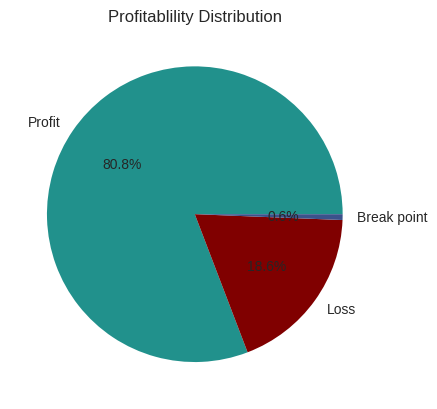

In [35]:
profit_count=df['Profitability Flag'].value_counts(normalize=True)*100
profit_count.plot(kind='pie',autopct='%1.1f%%',colors=[accent_color,danger_color,secondary_color])
plt.ylabel("")
plt.title("Profitablility Distribution")
plt.show()

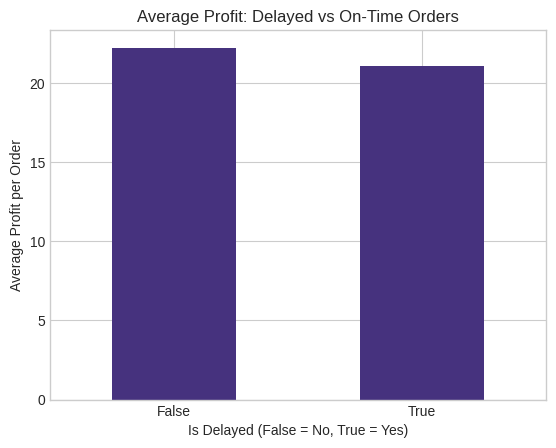

In [36]:
profit_by_status = df.groupby('Is_Delayed')['Order Profit Per Order'].mean()

profit_by_status.plot(kind='bar')
plt.title('Average Profit: Delayed vs On-Time Orders')
plt.xlabel('Is Delayed (False = No, True = Yes)')
plt.ylabel('Average Profit per Order')
plt.xticks(rotation=0)
plt.show()

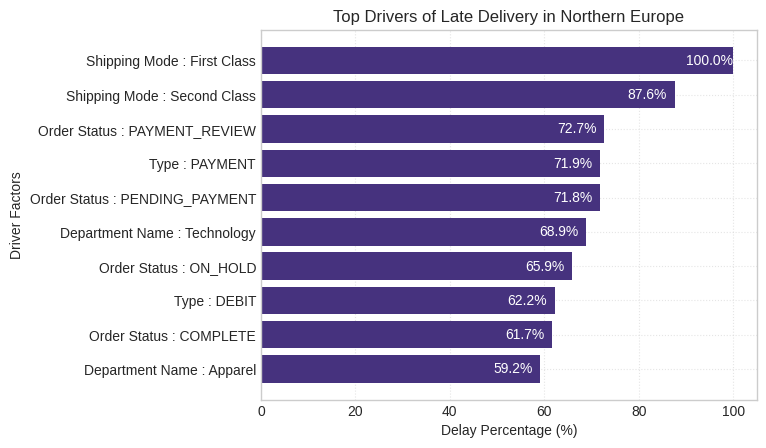

In [37]:
def top_drivers_for_region(region):
    df_region = df[df['Order Region'] == region].copy()
    drivers = [
    'Shipping Mode',
    'Customer Segment',
    'Department Name',
    'Type',
    'Order Status']
    all_factors = []
    for factor in drivers:
      temp = (
          df_region.groupby(factor).agg(
              total_orders=('Delay', 'count'),
              late_orders=('Is_Delayed', 'sum'),
              avg_delay=('Delay', 'mean')
              ).reset_index()
      )
      temp['delay_pct'] = (temp['late_orders'] / temp['total_orders']) * 100
      temp['Driver']=factor
      temp['Factor_Level'] = (factor + " : " + temp[factor].astype(str))

      all_factors.append(temp[['Driver', 'Factor_Level', 'delay_pct','avg_delay', 'total_orders']])

    final_df = pd.concat(all_factors)
    top_factors = (final_df.sort_values('delay_pct', ascending=False).head(10))
    plt.figure()
    bars = plt.barh(top_factors['Factor_Level'],top_factors['delay_pct'])
    plt.xlabel("Delay Percentage (%)")
    plt.ylabel("Driver Factors")
    plt.title(f"Top Drivers of Late Delivery in {region}")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().invert_yaxis()

    for bar in bars:
      width = bar.get_width()
      plt.text(width - 10,bar.get_y() + bar.get_height()/2,f"{width:.1f}%",va='center',fontsize=10,color='white')
    plt.show()
top_drivers_for_region('Northern Europe')

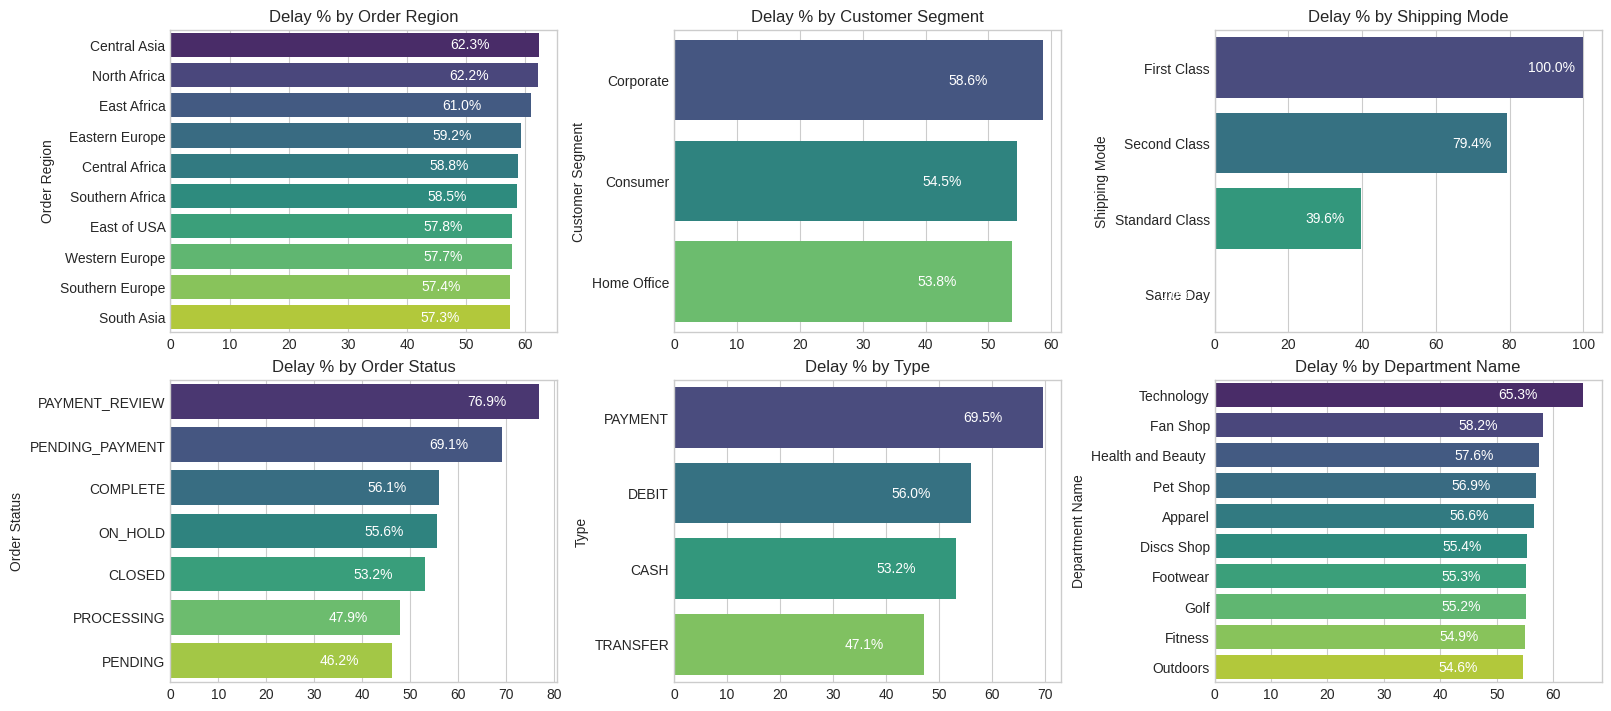

In [38]:
categories = [
    'Order Region',
    'Customer Segment',
    'Shipping Mode',
    'Order Status',
    'Type',
    'Department Name'
]
fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 7),
    constrained_layout=True
)
axes = axes.flatten()
for ax, category in zip(axes, categories):
  cat_df = compute_delay_pct_by_category(category)
  sns.barplot(
    data=cat_df,
    x='delay_pct',
    y=category,
    ax=ax,
    palette='viridis'
)
  ax.set_title(f'Delay % by {category}')
  ax.set_xlabel('')
  ax.set_ylabel(category)
  for i, row in cat_df.reset_index().iterrows():
    ax.text(
        row['delay_pct'] - 15,
        i,
        f"{row['delay_pct']:.1f}%",
        va='center',
        fontsize=10,
        color='white'
    )
plt.show()

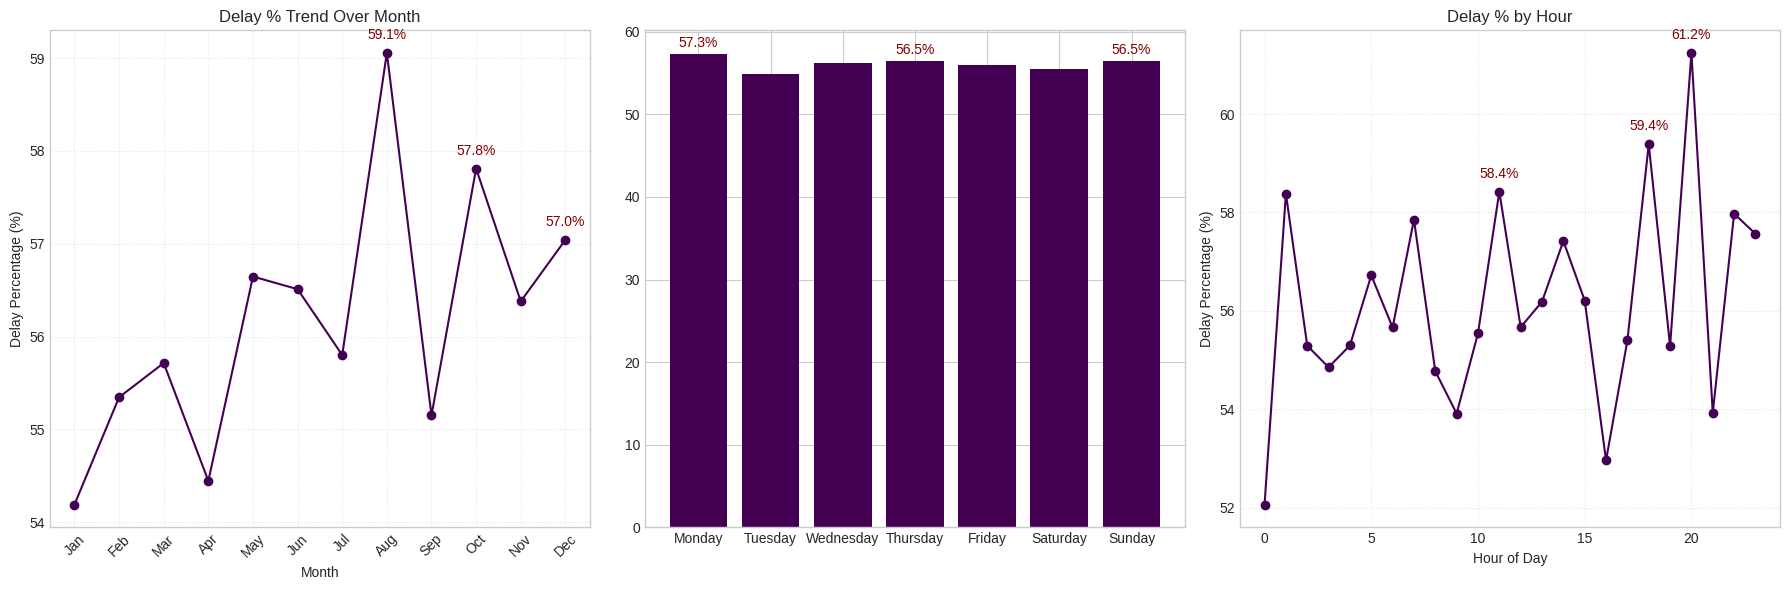

In [39]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
ax1.plot(
    delay_by_month['order_month'],
    delay_by_month['delay_pct'],
    marker='o',
    color=primary_color
)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    rotation=45
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay % Trend Over Month")
ax1.grid(True, linestyle=':', alpha=0.5)
top3_month = delay_by_month.nlargest(3, 'delay_pct')

for _, row in top3_month.iterrows():
    ax1.annotate(
        f"{row['delay_pct']:.1f}%",
        (row['order_month'], row['delay_pct']),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=10,
        color=danger_color
    )
day_order = [
    'Monday', 'Tuesday', 'Wednesday', 'Thursday',
    'Friday', 'Saturday', 'Sunday'
]

delay_by_day['order_day'] = pd.Categorical(
    delay_by_day['order_day'],
    categories=day_order,
    ordered=True
)

delay_by_day = delay_by_day.sort_values('order_day')
ax2.bar(
    delay_by_day['order_day'],
    delay_by_day['delay_pct'],
    color=primary_color
)
top3_day = delay_by_day.nlargest(3, 'delay_pct')

for _, row in top3_day.iterrows():
    height = row['delay_pct']

    ax2.text(
        row['order_day'],
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        color=danger_color
    )
ax3.plot(
    delay_by_hour['order_hour'],
    delay_by_hour['delay_pct'],
    marker='o',
    color=primary_color
)
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay % by Hour")
ax3.grid(True, linestyle=':', alpha=0.5)
top3_hour = delay_by_hour.nlargest(3, 'delay_pct')

for _, row in top3_hour.iterrows():
    ax3.annotate(
        f"{row['delay_pct']:.1f}%",
        (row['order_hour'], row['delay_pct']),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=10,
        color=danger_color
    )
plt.tight_layout()
plt.show()

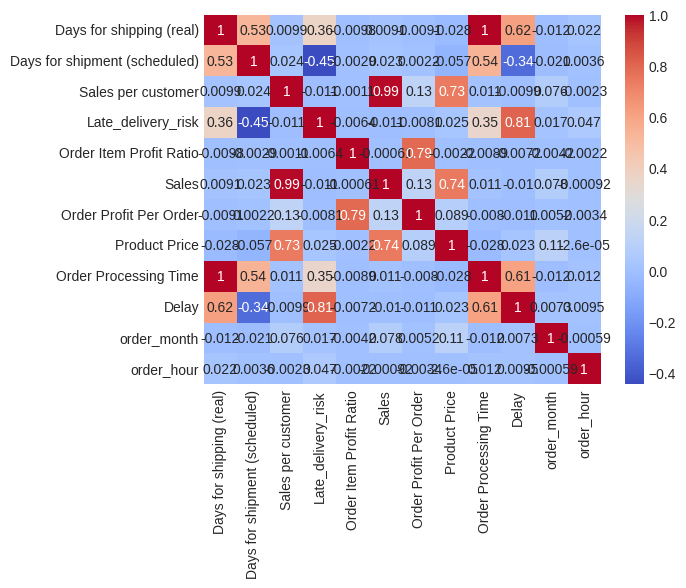

In [40]:
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

<Axes: xlabel='Days for shipping (real)', ylabel='Order Processing Time'>

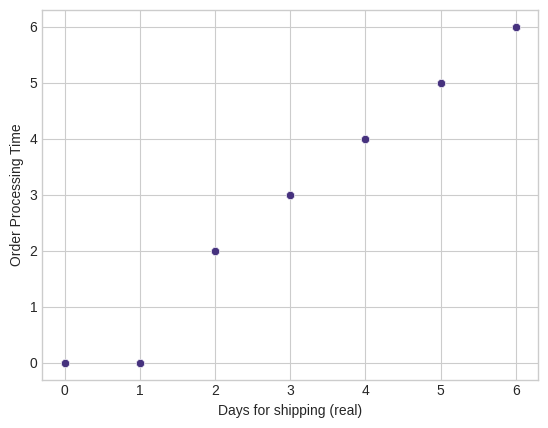

In [41]:
sns.scatterplot(x='Days for shipping (real)',y='Order Processing Time',data=df)

<Axes: xlabel='Order Processing Time', ylabel='Delay'>

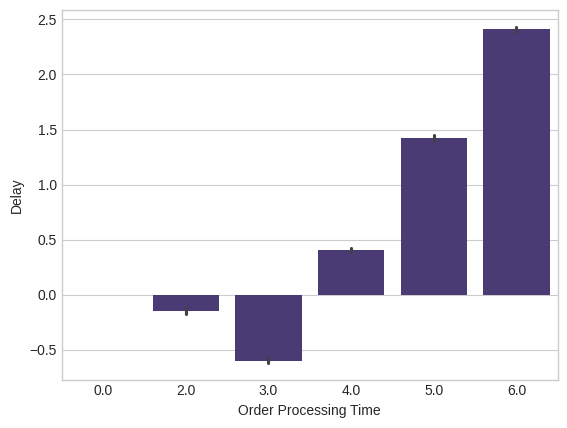

In [42]:
sns.barplot(data=df,x="Order Processing Time",y='Delay')

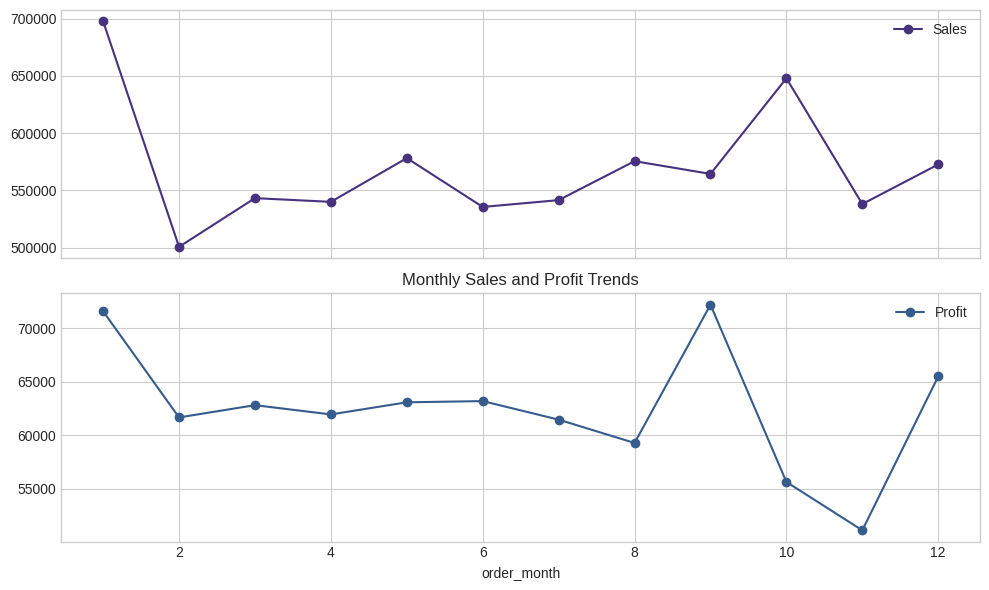

In [43]:
monthly = df.groupby('order_month').agg(
    Sales=('Sales', 'sum'),
    Profit=('Order Profit Per Order', 'sum')
)

monthly[['Sales', 'Profit']].plot(
    subplots=True, figsize=(10, 6), marker='o'
)
plt.title("Monthly Sales and Profit Trends")
plt.tight_layout()
plt.show()

## 8. Key Findings

### 1. Delivery Performance
- The dataset contains **11,323 orders**, of which **6,304 were classified as late deliveries**.
- The reported late delivery percentage is **55.67%**, while 44.33% of orders were not classified as late using the project's delay calculation.
- Shipping durations of 2 days were the most frequent, accounting for approximately 3,486 orders.
- These results indicate that delivery delays are an important area for operational improvement.

### 2. Shipping Delays and Scheduled Delivery Times
- Scheduled shipping durations were primarily 2 and 4 days.
- The analysis shows differences between scheduled shipping times and actual shipping durations.
- The delay distribution peaks at a one-day delay, suggesting that a substantial number of orders exceeded their scheduled shipping time by one day.
- Delivery performance should be evaluated consistently using the same definition of actual shipping duration and delay throughout the analysis.

### 3. Profitability Analysis
- Approximately **80.6% of orders were classified as profitable**, 18.8% as loss-making, and 0.6% as break-even.
- Average order profit was highest when shipping occurred one day before the scheduled time, at approximately $24.01.
- Average order profit was lowest for orders delayed by two days, at approximately $16.20.
- Orders delayed by three and four days had similar average profits, of approximately $19.93 and $19.78, respectively.
- These patterns show an association between shipping performance and profitability, but they do not establish that delays directly caused lower profits.

### 4. Regional Delivery Performance
- Northern Europe, East Africa, Southern Europe, the East of the USA, and Central Asia showed delay rates of around 60%.
- In Northern Europe, the observed delay rate was 100% for First Class and 86.8% for Second Class shipments.
- These regions and shipping categories are useful priorities for further investigation.
- Order counts should be checked before drawing conclusions from individual regional or shipping-mode percentages.

### 5. Shipping Mode, Payment Type, and Department
- First Class shipments showed a 100% delay rate in the analyzed data.
- Orders associated with cash payments had a delay rate of 72.3%.
- The Technology department had a delay rate of 71.2%.
- These findings identify groups that may require additional investigation into dispatch processes, payment-related workflows, and operational constraints.

### 6. Time-Based Delivery Patterns
- August had the highest reported monthly delay rate among the highlighted findings, at 62.7%.
- Tuesday had a delay rate of 58.0%.
- Orders placed at 20:00 had a delay rate of 62.0%.
- These patterns may help identify periods for closer monitoring, but further analysis is needed to determine whether workload, staffing, order volume, or other factors explain the differences.

### 7. Relationship Between Shipping and Order Processing
- The analysis showed a strong relationship between actual shipping duration and order processing time.
- Orders with zero or one day of actual shipping duration had an order processing time of zero in the observed data.
- The notebook also reported an 81% relationship between delay and late delivery risk. The exact correlation method and the variables used should be stated when presenting this result.
- Correlation indicates an association and should not be interpreted as proof of causation.

### 8. Monthly Sales and Profitability
- January showed higher monthly sales in the analyzed period.
- September and December showed higher profitability.
- These differences suggest that sales volume and profitability may follow different monthly patterns.
- Further analysis of order volume, average order profit, discounts, and product categories could help explain these differences.

## 9. Business Recommendations

### 1. Improve Delivery Performance
Monitor late deliveries regularly and investigate the reasons orders exceed their scheduled shipping durations. Establish clear delivery-performance targets and review progress over time.

### 2. Investigate High-Delay Regions
Prioritize Northern Europe, East Africa, Southern Europe, the East of the USA, and Central Asia for further analysis. Examine regional order volumes, warehouse locations, carrier performance, and shipping routes before selecting corrective actions.

### 3. Review Shipping-Mode Performance
Investigate the First Class delay rate and compare it with other shipping modes using order counts and consistent delay definitions. Check whether delays are associated with dispatch procedures, carrier capacity, or data-quality issues.

### 4. Examine Payment and Department Workflows
Investigate the high delay rates associated with cash payments and the Technology department. Review order processing stages and handoffs to identify potential bottlenecks rather than assuming that payment type or department directly causes delays.

### 5. Plan for High-Delay Periods
Monitor delivery performance in August, on Tuesdays, and for orders placed around 20:00. Compare delay rates with order volumes and staffing levels to determine whether additional operational capacity or scheduling changes would be useful.

### 6. Monitor Profitability Alongside Delivery Performance
Track delivery delay rates and order profitability together. Investigate whether delayed orders also have higher costs, lower margins, or other differences. Use net profit and clearly defined loss measures rather than treating the total profit of delayed orders as a financial loss.

### 7. Develop a Supply Chain Performance Dashboard
Create a dashboard in Power BI or another visualization tool to monitor:
- Total orders and late deliveries
- Late, on-time, and early delivery percentages
- Average shipping duration and delivery delay
- Regional and shipping-mode performance
- Profitability by delay duration
- Monthly sales and profitability trends

This dashboard would help stakeholders identify changing delivery patterns and prioritize areas for investigation.

## 10. Limitations

- The analysis is based on historical order data and may not represent future supply chain performance.
- Observed relationships do not prove that a particular factor caused a delay or a change in profitability.
- Delay rates for small groups may be unstable and should be interpreted alongside their order counts.
- Date-based shipping duration and the dataset's reported shipping duration may differ; the chosen measure should be validated and applied consistently.
- The reported profit and loss metrics must be clearly defined. The sum of positive order profits is not net profit, and the sum of profits for delayed orders is not the same as losses caused by delays.

## 11. Conclusion

This project used Python-based data analysis to investigate supply chain delivery performance, shipping delays, profitability, regional patterns, and monthly trends. The findings highlight a substantial proportion of late deliveries and identify several regions, shipping categories, and time periods that warrant further investigation.

The analysis also shows differences in average order profitability across delay durations. However, these relationships should be interpreted as associations rather than causal effects.

By improving delivery monitoring, investigating operational bottlenecks, validating performance metrics, and tracking profitability alongside shipping performance, the organization can make more informed, data-driven supply chain decisions.